### Reading data and creating features

In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("/workspaces/hotel-demand-forecasting/data/hotel_daily_booking_data_2024_2025.xlsx",skiprows=1)
df['date'] = pd.to_datetime(df['date'])

In [2]:
print(df.shape)

(2193, 9)


In [3]:
df = df.sort_values(['room_type','date'])

In [4]:
df['month'] = df['date'].dt.month
#df['day'] = df['date'].dt.day
df['week'] = df['date'].dt.isocalendar().week.astype(int)

In [5]:
df = df.sort_values(['room_type', 'date'])

df['lag_1'] = df.groupby('room_type')['bookings'].shift(1)


df['lag_7'] = df.groupby('room_type')['bookings'].shift(7)


df['rolling_7'] =  df.groupby('room_type')['bookings'].transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
df['price_lag_1']      = df.groupby('room_type')['price_inr'].shift(1)
df['price_lag_7']      = df.groupby('room_type')['price_inr'].shift(7)
df['price_rolling_7']  = df.groupby('room_type')['price_inr'].transform(lambda x: x.shift(1).rolling(7).mean())


df = df.dropna(subset=['lag_1', 'lag_7', 'rolling_7', 'price_lag_1', 'price_lag_7', 'price_rolling_7'])



In [6]:
from sklearn.preprocessing import LabelEncoder
encoders = {}
for col in ['room_type','day_of_week']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df = pd.get_dummies(df,columns=['event_name'],drop_first=True)

In [11]:
print(encoders['day_of_week'].classes_)
print(encoders['room_type'].classes_)

['Friday' 'Monday' 'Saturday' 'Sunday' 'Thursday' 'Tuesday' 'Wednesday']
['Deluxe' 'Standard' 'Suite']


In [ ]:
#future['room_type'] = encoders['room_type'].inverse_transform(future['room_type'])
#encoders['room_type'].inverse_transform(future['room_type'])


In [12]:
print(df.columns)

Index(['date', 'room_type', 'bookings', 'price_inr', 'occupancy_pct',
       'event_flag', 'day_of_week', 'is_weekend', 'month', 'week', 'lag_1',
       'lag_7', 'rolling_7', 'price_lag_1', 'price_lag_7', 'price_rolling_7',
       'event_name_Diwali', 'event_name_New Year', 'event_name_Tamil New Year',
       'event_name_Valentine's Day'],
      dtype='str')


#### Creating training and validation data . Validation is the last 30 days data

In [13]:
df = df.sort_values(['room_type', 'date'])

In [14]:
cutoff_date = (df['date'].max() - pd.Timedelta(days=30))
train_df = df[df['date'] <= cutoff_date]
val_df = df[df['date'] > cutoff_date]

print(cutoff_date)
print(train_df['date'].min(), train_df['date'].max())
print(val_df['date'].min(), val_df['date'].max())

2025-12-01 00:00:00
2024-01-08 00:00:00 2025-12-01 00:00:00
2025-12-02 00:00:00 2025-12-31 00:00:00


#### XGboost fine tuning with NO PRICE features 

In [15]:
y = df['bookings']
features = ['room_type', 'day_of_week','is_weekend','month',
            'week', 'lag_1','lag_7','rolling_7', 'event_name_Diwali',
            'event_name_New Year','event_name_Tamil New Year',
            "event_name_Valentine's Day"]

In [16]:
X_train = train_df[features]
y_train = train_df['bookings']

X_val = val_df[features]
y_val = val_df['bookings']

In [17]:
X_train.head()

,room_type,day_of_week,is_weekend,month,week,lag_1,lag_7,rolling_7,event_name_Diwali,event_name_New Year,event_name_Tamil New Year,event_name_Valentine's Day
21,0,1,0,1,2,46.0,57.0,48.428571,False,False,False,False
24,0,5,0,1,2,34.0,51.0,45.142857,False,False,False,False
27,0,6,0,1,2,35.0,41.0,42.857143,False,False,False,False
30,0,4,0,1,2,32.0,39.0,41.571429,False,False,False,False
33,0,0,1,1,2,33.0,47.0,40.714286,False,False,False,False


In [18]:
def evaluate(name, model, X, y):
    preds = model.predict(X)
    mae  = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    mape = np.mean(np.abs((y - preds) / y.clip(lower=1))) * 100
    print(f"{name:10s} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.1f}%")
    return preds


In [22]:
import optuna
#import lightgbm as lgb
from xgboost import XGBRegressor
#from lightgbm import LGBMRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'early_stopping_rounds': 50,   # ← moved here
        'eval_metric': 'mae',          # ← moved here too
        'random_state': 42
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return mean_absolute_error(y_val, model.predict(X_val))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)
print("Best params:", study.best_params)

[I 2026-06-13 17:09:38,443] A new study created in memory with name: no-name-16c25c6a-6aa9-44ee-9cc0-ad50cdbcff01
[I 2026-06-13 17:09:38,691] Trial 0 finished with value: 2.977264404296875 and parameters: {'n_estimators': 751, 'max_depth': 6, 'learning_rate': 0.09521852936542903, 'subsample': 0.8370025666648281, 'colsample_bytree': 0.9782427635017947}. Best is trial 0 with value: 2.977264404296875.
[I 2026-06-13 17:09:38,886] Trial 1 finished with value: 3.1840898990631104 and parameters: {'n_estimators': 495, 'max_depth': 7, 'learning_rate': 0.06567297923173804, 'subsample': 0.9840662516878447, 'colsample_bytree': 0.8153142257712139}. Best is trial 0 with value: 2.977264404296875.
[I 2026-06-13 17:09:39,211] Trial 2 finished with value: 2.9145469665527344 and parameters: {'n_estimators': 897, 'max_depth': 8, 'learning_rate': 0.05769431597715917, 'subsample': 0.7226644606850748, 'colsample_bytree': 0.7018807062677912}. Best is trial 2 with value: 2.9145469665527344.
[I 2026-06-13 17:09

Best params: {'n_estimators': 788, 'max_depth': 3, 'learning_rate': 0.06843041353714463, 'subsample': 0.6798526608338618, 'colsample_bytree': 0.8714706679583251}


In [ ]:
#Best params: {'n_estimators': 624, 'max_depth': 3, 'learning_rate': 0.09033795549128364, 
#'subsample': 0.7555651059443409, 'colsample_bytree': 0.8253954417760043}

In [24]:
best_xgb = XGBRegressor(
    **study.best_params,
    early_stopping_rounds=50,
    eval_metric='mae',
    random_state=42
)
best_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

xgb_best_pred = evaluate("XGBoost (Tuned) Test", best_xgb, X_val, y_val)
xgb_best_trainpred = evaluate("XGBoost (Tuned) Train", best_xgb, X_train, y_train)

XGBoost (Tuned) Test | MAE: 2.74 | RMSE: 3.78 | MAPE: 7.7%
XGBoost (Tuned) Train | MAE: 1.59 | RMSE: 2.23 | MAPE: 6.0%


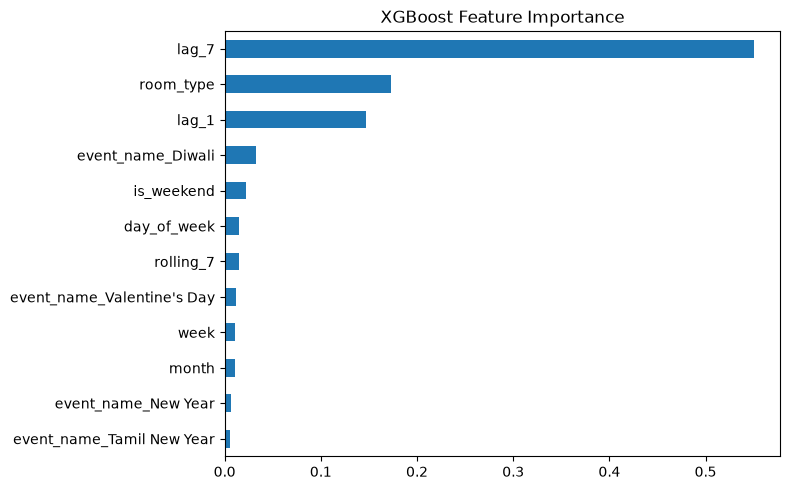

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(best_xgb.feature_importances_, index=features)
importance.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
#print(xgb_best_pred,y_val)

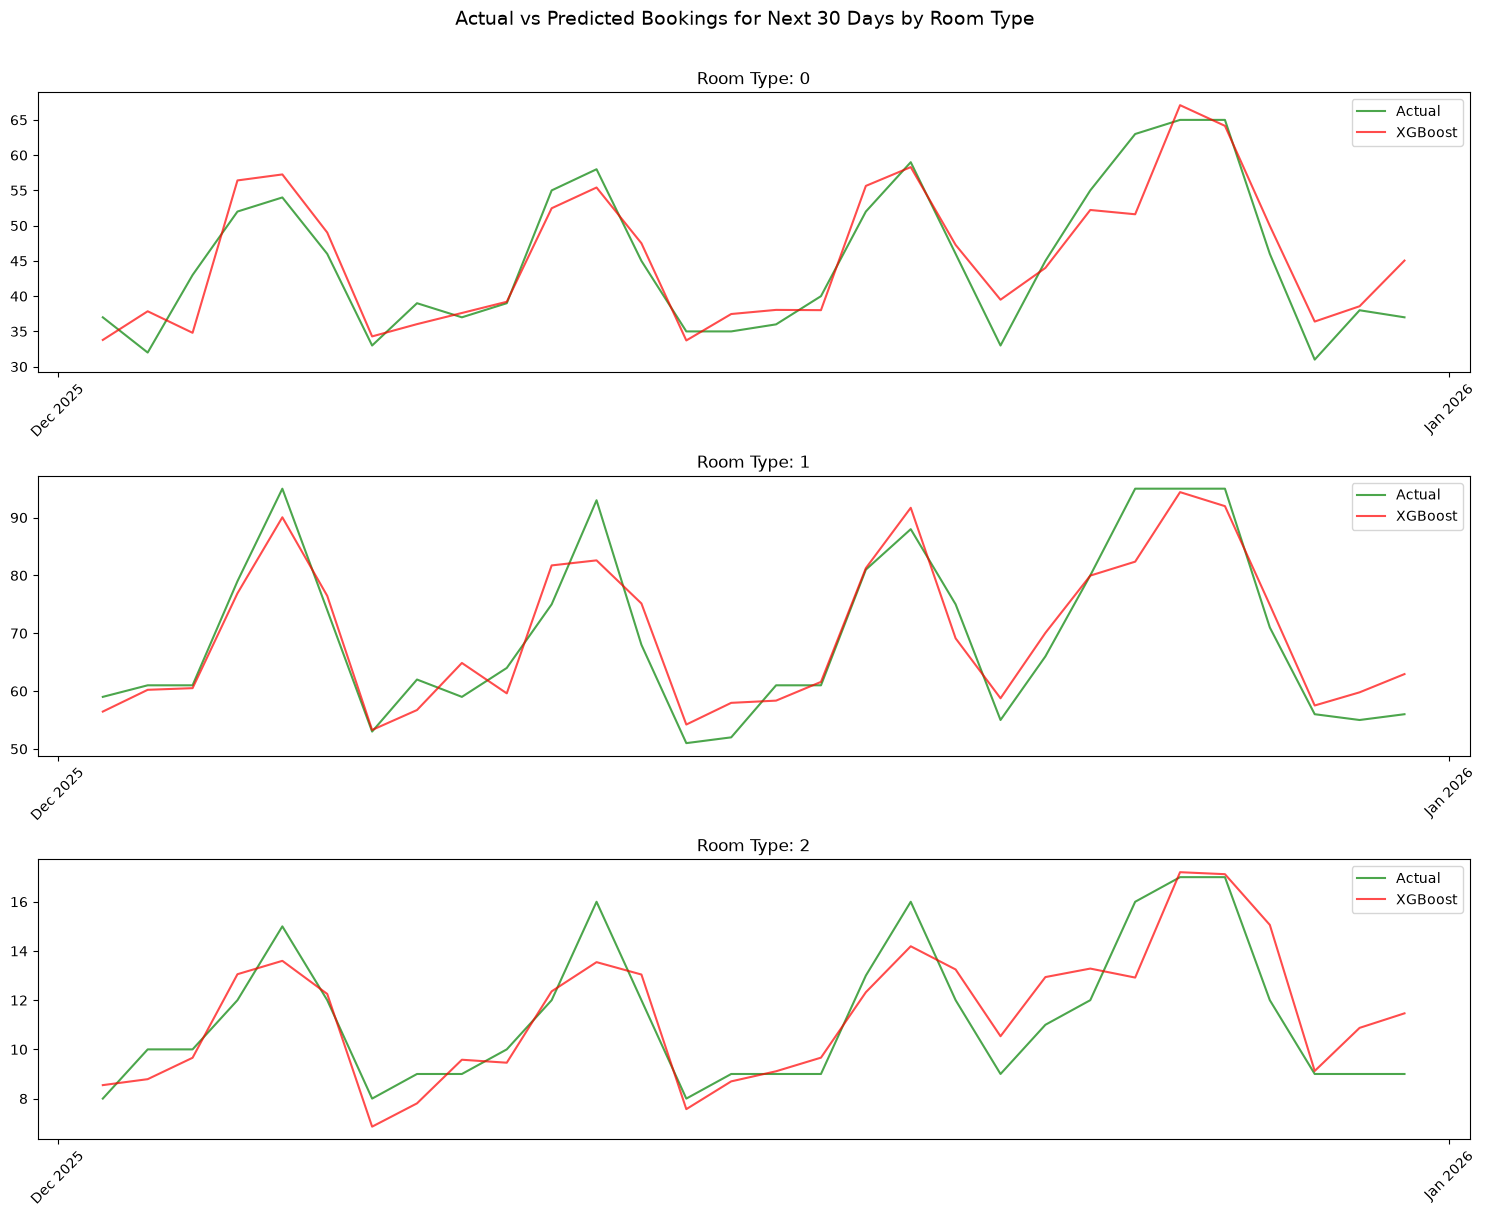

In [26]:
import matplotlib.dates as mdates
fig, axes = plt.subplots(len(val_df['room_type'].unique()), 1, 
                          figsize=(15, 4 * len(val_df['room_type'].unique())))

for ax, room in zip(axes, val_df['room_type'].unique()):
    mask = val_df['room_type'] == room
    
    ax.plot(val_df.loc[mask, 'date'], y_val[mask].values, 
            label='Actual', color='green', alpha=0.7)
    ax.plot(val_df.loc[mask, 'date'], xgb_best_pred[mask], 
            label='XGBoost', color='red', alpha=0.7)
    
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(f"Room Type: {room}")
    ax.legend()

plt.suptitle("Actual vs Predicted Bookings for Next 30 Days by Room Type", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Added price features with lag and rolling metric

In [27]:
y = df['bookings']
features_price = [
    'room_type', 'day_of_week', 'is_weekend', 'month', 'week',
    'lag_1', 'lag_7', 'rolling_7',
    'price_lag_1', 'price_lag_7', 'price_rolling_7',   # ← new
    'event_name_Diwali', 'event_name_New Year',
    'event_name_Tamil New Year', "event_name_Valentine's Day"
]


In [28]:
X_train = train_df[features_price]
y_train = train_df['bookings']

X_val = val_df[features_price]
y_val = val_df['bookings']

#### Xgboost fine tuning with PRICE features

In [29]:
# ── 1. Tune XGBoost ─────────────────────────────────────────────────────────
def xgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1000),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 0.5),
        'early_stopping_rounds': 50,
        'eval_metric': 'mae',
        'random_state': 42
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return mean_absolute_error(y_val, model.predict(X_val))

xgb_study = optuna.create_study(direction='minimize')
xgb_study.optimize(xgb_objective, n_trials=50)
print("Best XGBoost MAE:", xgb_study.best_value)
print("Best XGBoost params:", xgb_study.best_params)

# ── 3. Train final models with best params ──────────────────────────────────
final_xgb_price = XGBRegressor(
    **xgb_study.best_params,
    early_stopping_rounds=50,
    eval_metric='mae',
    random_state=42
)
final_xgb_price.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

[I 2026-06-13 17:10:51,338] A new study created in memory with name: no-name-3cb28135-8a39-4ff4-9b66-be74d1558cd5
[I 2026-06-13 17:10:51,592] Trial 0 finished with value: 2.909621477127075 and parameters: {'n_estimators': 405, 'max_depth': 3, 'learning_rate': 0.04641989680918334, 'subsample': 0.9699743664381806, 'colsample_bytree': 0.7952046272571451, 'min_child_weight': 7, 'gamma': 0.3708363896532321}. Best is trial 0 with value: 2.909621477127075.
[I 2026-06-13 17:10:51,966] Trial 1 finished with value: 2.9647915363311768 and parameters: {'n_estimators': 775, 'max_depth': 3, 'learning_rate': 0.03682309428354966, 'subsample': 0.8785284923941066, 'colsample_bytree': 0.785403299624962, 'min_child_weight': 7, 'gamma': 0.4255550436730811}. Best is trial 0 with value: 2.909621477127075.
[I 2026-06-13 17:10:52,164] Trial 2 finished with value: 3.043686628341675 and parameters: {'n_estimators': 283, 'max_depth': 3, 'learning_rate': 0.08903128677722558, 'subsample': 0.9100903361481595, 'colsa

Best XGBoost MAE: 2.6368777751922607
Best XGBoost params: {'n_estimators': 941, 'max_depth': 4, 'learning_rate': 0.0921591380492672, 'subsample': 0.7921577013855162, 'colsample_bytree': 0.6640236586446638, 'min_child_weight': 2, 'gamma': 0.2059194545484886}


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6640236586446638
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'mae'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [30]:
xgbprice_best_pred = evaluate("XGBoost (Tuned) Test", final_xgb_price, X_val, y_val)
xgbprice_best_trainpred = evaluate("XGBoost (Tuned) Train", final_xgb_price, X_train, y_train)

XGBoost (Tuned) Test | MAE: 2.64 | RMSE: 3.73 | MAPE: 6.6%
XGBoost (Tuned) Train | MAE: 1.31 | RMSE: 1.82 | MAPE: 5.0%


In [31]:
val_result = val_df[['date','room_type','bookings']].copy()

val_result['prediction_xgb'] = xgb_best_pred
val_result['prediction_xgb_price'] = xgbprice_best_pred

val_result['median_bookings'] = val_result[['prediction_xgb','prediction_xgb_price']].median(axis=1)

In [32]:
val_result.head(10)

,date,room_type,bookings,prediction_xgb,prediction_xgb_price,median_bookings
2103,2025-12-02,0,37,33.789177,33.890465,33.839821
2106,2025-12-03,0,32,37.855736,37.648201,37.751968
2109,2025-12-04,0,43,34.801849,33.436710,34.119278
2112,2025-12-05,0,52,56.414482,55.085938,55.750210
2115,2025-12-06,0,54,57.264938,56.251385,56.758163
2118,2025-12-07,0,46,49.025196,49.335575,49.180386
2121,2025-12-08,0,33,34.291595,34.129093,34.210342
2124,2025-12-09,0,39,36.032406,35.312160,35.672283
2127,2025-12-10,0,37,37.613041,36.755169,37.184105
2130,2025-12-11,0,39,39.204807,38.814564,39.009686


In [33]:
mae  = mean_absolute_error(val_result['bookings'], val_result['median_bookings'])
rmse = np.sqrt(mean_squared_error(val_result['bookings'], val_result['median_bookings']))
mape = np.mean(np.abs((val_result['bookings']-val_result['median_bookings']) / y.clip(lower=1))) * 100
print(f" MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.1f}%")

 MAE: 2.65 | RMSE: 3.68 | MAPE: 7.0%


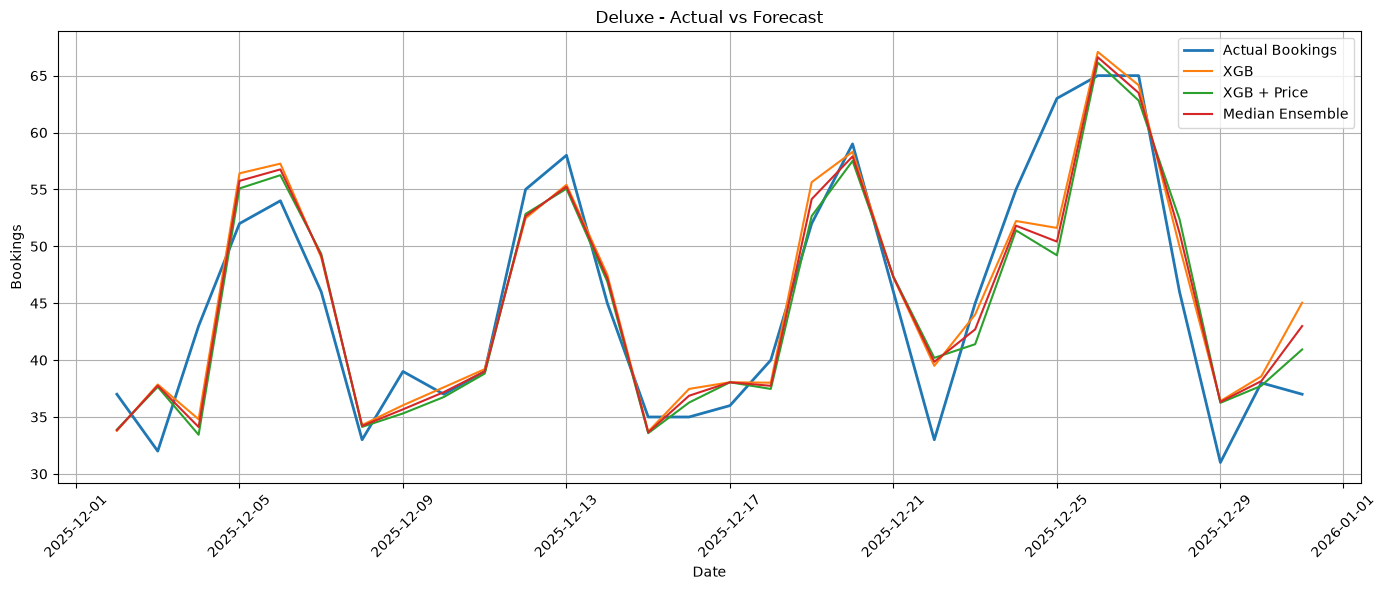

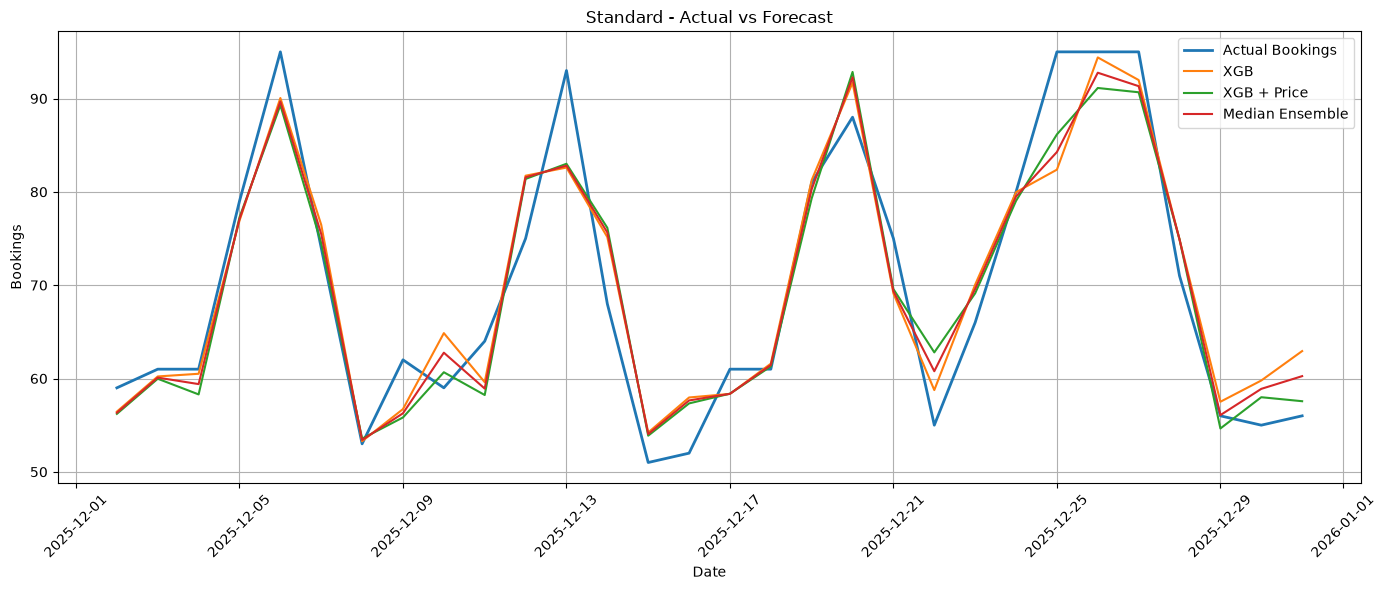

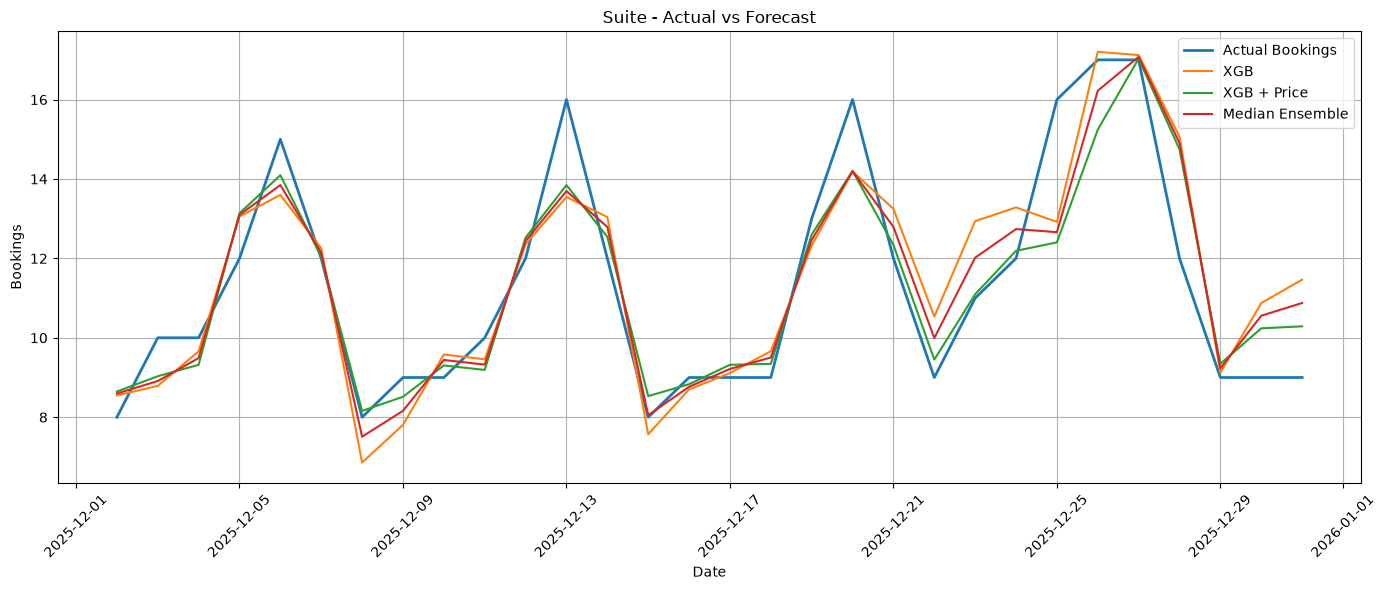

In [34]:
import matplotlib.pyplot as plt

room_map = {
    0: 'Deluxe',
    1: 'Standard',
    2: 'Suite'
}

for room in sorted(val_result['room_type'].unique()):

    temp = (
        val_result[val_result['room_type'] == room]
        .sort_values('date')
    )

    plt.figure(figsize=(14,6))

    plt.plot(
        temp['date'],
        temp['bookings'],
        label='Actual Bookings',
        linewidth=2
    )

    plt.plot(
        temp['date'],
        temp['prediction_xgb'],
        label='XGB'
    )

    plt.plot(
        temp['date'],
        temp['prediction_xgb_price'],
        label='XGB + Price'
    )

    plt.plot(
        temp['date'],
        temp['median_bookings'],
        label='Median Ensemble'
    )

    plt.title(f"{room_map.get(room, room)} - Actual vs Forecast")
    plt.xlabel("Date")
    plt.ylabel("Bookings")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

In [35]:
val_result['room_type'] = encoders['room_type'].inverse_transform(val_result['room_type'])

In [36]:
val_result.head()

,date,room_type,bookings,prediction_xgb,prediction_xgb_price,median_bookings
2103,2025-12-02,Deluxe,37,33.789177,33.890465,33.839821
2106,2025-12-03,Deluxe,32,37.855736,37.648201,37.751968
2109,2025-12-04,Deluxe,43,34.801849,33.436710,34.119278
2112,2025-12-05,Deluxe,52,56.414482,55.085938,55.750210
2115,2025-12-06,Deluxe,54,57.264938,56.251385,56.758163


In [ ]:
#val_result.to_csv("C:/Users/Shraddha/Downloads/hotel_booking_models/hotel_booking/hotel_booking_forecast.csv")

In [37]:
import joblib

joblib.dump(best_xgb, '/workspaces/hotel-demand-forecasting/models/hotel_demand_xgb.pkl')

joblib.dump(final_xgb_price, '/workspaces/hotel-demand-forecasting/models/hotel_demand_xgb_price.pkl')
joblib.dump(features_price, '/workspaces/hotel-demand-forecasting/models/features.pkl')
joblib.dump(  encoders,  '/workspaces/hotel-demand-forecasting/models/label_encoders.pkl')

['/workspaces/hotel-demand-forecasting/models/label_encoders.pkl']